In [1]:
import os
import csv
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from datetime import datetime

%matplotlib notebook
%matplotlib inline
mpl.use('Agg')  # Use non-interactive backend
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern']
plt.rcParams['font.size'] = 20

laser_color = np.array([183, 86, 89])/255
laser_color_saturated = np.array([184,0,6])/255
mic_color = np.array([214, 174, 114])/255

In [2]:
def read_data(data_directory, file_name, downsampling=1):
    data = []
    time_axis = []
    timestamps = []
    i = 0
    first = True
    with open(os.path.join(data_directory, file_name), 'r', newline='') as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=';')
        header = next(csv_reader)
        for row in csv_reader:
            timestamps.append(row[0])
            
            timestamp = datetime.strptime(row[0], '%Y-%m-%d %H:%M:%S.%f')
            if first:
                first_timestamp = timestamp
            if not first:
                time_axis += list(np.linspace((prev_timestamp - first_timestamp).total_seconds(),
                                              (timestamp - first_timestamp).total_seconds(), len(row) - 1, endpoint=False))
            i += 1
            data.append(np.array(row[1:]).astype('float'))
            prev_timestamp = timestamp
            first = False
        print(i)
    data = np.array(data[:-1]).reshape((1, np.size(data[:-1]))).flatten()  # reject last data row because no timestamps are estimated for it
    print(f'Original data shape: {data.shape}')
    data_downsampled = data[::downsampling]
    print(f'Downsampled data shape: {data_downsampled.shape}')
    return data_downsampled, header, timestamps, time_axis

In [3]:
def get_time_data(data, fs, view_range, x_time=True):
    time_axis_offset = 0
    if view_range:
        data = data[view_range[0]:view_range[1]]
    else:
        view_range = (0, data.size)
        print(f'No view range passed, using {view_range}')
    data_ac = data - np.mean(data)

    if x_time:
        time_axis = [(view_range[0] + i) / fs for i in range(len(data))]
        return time_axis, data
    else:
        time_axis = [view_range[0] + i for i in range(len(data))]
        return time_axis, data
    
def plot_data(data, fs, view_range, x_time=True):
    time_axis, data = get_time_data(data, fs, view_range, x_time=True)
    plt.plot(time_axis, data)
    if x_time:
        plt.xlabel("time [s]")
    else:
        plt.xlabel("sample")
    plt.ylabel("[V]")

In [4]:
def get_fft_data(data, fs, fft_range, view_range):
    if fft_range:
        fft_range[1] = min(fft_range[1], len(data))
        data = data[fft_range[0]:fft_range[1]]
    data_ac = data - np.mean(data)
    # print(f'data size: {data_ac.shape}')
    data_fft = np.abs(np.fft.fft(data_ac))
    # print(f'fft size: {data_fft.shape}')

    num_samples = data_fft.size
    if view_range:
        data_fft = data_fft[round(view_range[0] / fs * num_samples):
                            round(min(view_range[1], fs) / fs * num_samples)]
        freq = np.linspace(view_range[0], min(view_range[1], fs), data_fft.size)
        return freq, data_fft
    else:
        freq = np.linspace(0, fs, data_fft.size)
        return freq, data_fft
    
def plot_fft(data, fs, fft_range, view_range):
    freq, data_fft = get_fft_data(data, fs, fft_range, view_range)
    plt.plot(freq, data_fft)
    plt.xlabel("f [Hz]")
    plt.ylabel("FFT")

In [5]:
def parse_sensor_data(data_directory, laser_file_name, mic_file_name, 
                      downsampling, mic_signal_range, laser_signal_range, 
                      mic_rest_range, laser_rest_range, time_axis_offset=0):
    mic_data, mic_header, mic_timestamps, mic_time_axis = read_data(data_directory, mic_file_name, downsampling)
    mic_time_axis = np.array(mic_time_axis) - time_axis_offset
    mic_start_timestamp = datetime.strptime(mic_timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
    time1 = datetime.strptime(mic_timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
    time2 = datetime.strptime(mic_timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
    mic_time_difference = (time2 - time1).total_seconds()
    mic_fs = len(mic_data)/mic_time_difference / downsampling
    print(f'fs: {mic_fs}')

    mic_data = mic_data - np.mean(mic_data)
    mic_rest_power = np.sum((np.array(mic_data[mic_rest_range[0]:mic_rest_range[1]]) - np.mean(mic_data[mic_rest_range[0]:mic_rest_range[1]]))**2)/len(list(mic_data[mic_rest_range[0]:mic_rest_range[1]]))
    mic_signal_power = np.sum((np.array(mic_data[mic_signal_range[0]:mic_signal_range[1]]) - np.mean(mic_data[mic_signal_range[0]:mic_signal_range[1]]))**2)/len(list(mic_data[mic_signal_range[0]:mic_signal_range[1]]))
    mic_sensitivity = np.sqrt(mic_signal_power/mic_rest_power)
    print(f'MIC rest_power: {mic_rest_power:.2f} ; signal_power: {mic_signal_power:.2f}; sensitivity: {mic_sensitivity:.2f}={20*np.log10(mic_sensitivity):.1f}dB ')


    laser_data, laser_header, laser_timestamps, laser_time_axis = read_data(data_directory, laser_file_name, downsampling)
    laser_start_timestamp = datetime.strptime(laser_timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
    laser_time_axis = np.array(laser_time_axis) + (laser_start_timestamp - mic_start_timestamp).total_seconds() - time_axis_offset
    time1 = datetime.strptime(laser_timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
    time2 = datetime.strptime(laser_timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
    laser_time_difference = (time2 - time1).total_seconds()
    laser_fs = len(laser_data)/laser_time_difference / downsampling
    print(f'fs: {laser_fs}')

    laser_data = np.array(laser_data - np.mean(laser_data))
    laser_rest_power = np.sum((laser_data[laser_rest_range[0]:laser_rest_range[1]] - np.mean(laser_data[laser_rest_range[0]:laser_rest_range[1]]))**2)/len(list(laser_data[laser_rest_range[0]:laser_rest_range[1]]))
    laser_signal_power = np.sum((laser_data[laser_signal_range[0]:laser_signal_range[1]] - np.mean(laser_data[laser_signal_range[0]:laser_signal_range[1]]))**2)/len(list(laser_data[laser_signal_range[0]:laser_signal_range[1]]))
    laser_sensitivity = np.sqrt(laser_signal_power/laser_rest_power)
    print(f'LASER rest_power: {laser_rest_power:.2f} ; signal_power: {laser_signal_power:.2f}; sensitivity: {laser_sensitivity:.2f}={20*np.log10(laser_sensitivity):.1f}dB ')

    print(f'-------------- Laser is {laser_sensitivity/mic_sensitivity:.2f}={20*np.log10(laser_sensitivity/mic_sensitivity):.1f}dB times more sensitive than mic')
    
    return laser_data, laser_time_axis, laser_rest_power, mic_data, mic_time_axis, mic_rest_power

# Motor

In [26]:
%matplotlib notebook
from matplotlib.widgets import Button, Slider

downsampling = 1
data_directory = os.path.join(os.getcwd(), "motor")

file_names = ['motor_500_v2.csv', 'motor_500_v2.csv', 'motor_1000_v2.csv']
fft_ranges = [[323, 3249], [5653, 8580], [6282, 9111]]
colors = [np.array([0, 181, 139])/255, np.array([184,0,6])/255, np.array([64, 144, 214])/255, np.array([125, 181, 168])/255]
colors = [np.array([125, 181, 168])/255, np.array([67, 74, 82])/255, np.array([214, 174, 114])/255]

all_fft_data = {}

fig = plt.figure(figsize=(7, 5), constrained_layout=True)
plt.axvline(-10, linewidth=5, color=colors[0])
plt.axvline(-10, linewidth=5, color=colors[1])
plt.axvline(-10, linewidth=5, color=colors[2])
for i, file_name in enumerate(file_names):
    data, header, timestamps, _ = read_data(data_directory, file_name, downsampling)
    time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
    time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
    time_difference = (time2 - time1).total_seconds()
    fs = len(data)/time_difference / downsampling
    freq, data_fft = get_fft_data(data, fs, fft_ranges[i], [0, 1000])
    plt.plot(freq, abs(data_fft)/np.sqrt(np.sum(data_fft**2)), color=colors[i])
plt.legend(["Motor off", "500 steps/s", "1000 steps/s"])
plt.xlim([0, 1000])
plt.xlabel("Frequency [Hz]")
plt.ylabel("$|$FFT$|$/$\Sigma$$|$FFT$|$$^2$")
#plt.savefig('vibrometer_plot.png')  # Saves the figure as a PNG file
plt.show()

# Cable

## Cable slow

<IPython.core.display.Javascript object>


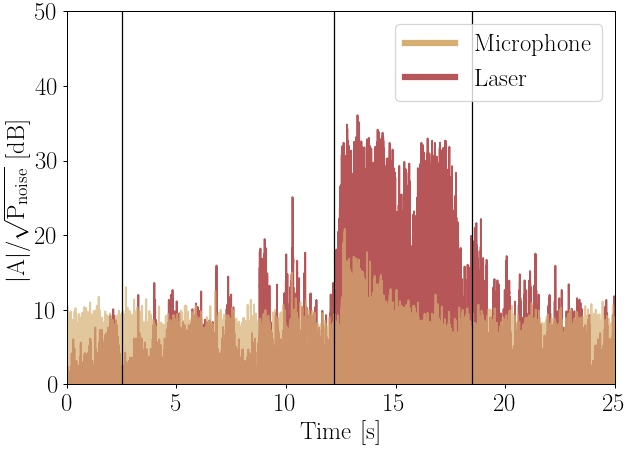

12191
Original data shape: (609500,)
Downsampled data shape: (609500,)
fs: 20176.97741661595
MIC rest_power: 11231982.68 ; signal_power: 16617040.23; sensitivity: 1.22=1.7dB 
1040
Original data shape: (103900,)
Downsampled data shape: (103900,)
fs: 3634.801838754943
LASER rest_power: 0.00 ; signal_power: 0.03; sensitivity: 12.92=22.2dB 
-------------- Laser is 10.62=20.5dB times more sensitive than mic


In [34]:
%matplotlib notebook

time_axis_offset = 1.5
downsampling = 1
fig = plt.figure(figsize=(7, 5), constrained_layout=True)
data_directory = os.path.join(os.getcwd(), "cable")

laser_data, laser_time_axis, laser_rest_power, mic_data, mic_time_axis, mic_rest_power = parse_sensor_data(
    data_directory=data_directory, mic_file_name='cable_mic4.csv', laser_file_name='cable_laser4.csv', 
    downsampling=downsampling, time_axis_offset=time_axis_offset, 
    mic_signal_range=(int(277000/downsampling), int(403500/downsampling)), laser_signal_range=(int(45500/downsampling), int(67200/downsampling)),
    mic_rest_range=(0, int(6e4/downsampling)), laser_rest_range=(int(70000/downsampling), -1))



plt.axvline(-10, linewidth=5, color=mic_color)
plt.axvline(-10, linewidth=5, color=laser_color)

plt.plot(laser_time_axis[::downsampling], 20*np.log10(abs(laser_data/np.sqrt(laser_rest_power))), alpha=1, color=laser_color)
plt.plot(mic_time_axis[::downsampling], 20*np.log10(abs(mic_data/np.sqrt(mic_rest_power))), alpha=0.7, color=mic_color)
#plt.plot(20*np.log10(abs(laser_data/np.sqrt(laser_rest_power))), alpha=1, color=laser_color)
#plt.plot(mic_time_axis[::downsampling], 20*np.log10(abs(mic_data/np.sqrt(mic_rest_power))), alpha=0.7, color=mic_color)

plt.axvline(4-time_axis_offset, linewidth=1, color='black')
plt.axvline(13.7-time_axis_offset, linewidth=1, color='black')
plt.axvline(20-time_axis_offset, linewidth=1, color='black')

plt.xlim([0, 25])
plt.ylim([0, 50])
plt.xlabel('Time [s]')
plt.ylabel('$|$A$|$/$\sqrt{\mathrm{P}_{\mathrm{noise}}}$ [dB]')
plt.legend(["Microphone", "Laser"])
plt.show()


plt.savefig('cable_plot.svg')

## Cable fast

<IPython.core.display.Javascript object>


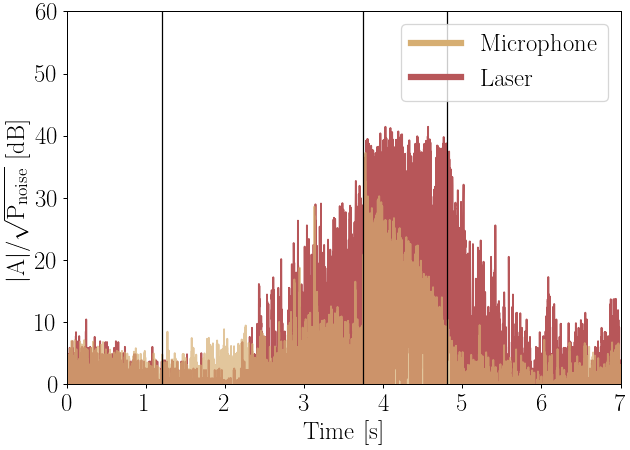

10300
Original data shape: (514950,)
Downsampled data shape: (514950,)
fs: 19558.179973768227
MIC rest_power: 34893595.52 ; signal_power: 856514701.01; sensitivity: 4.95=13.9dB 
895
Original data shape: (89400,)
Downsampled data shape: (89400,)
fs: 3634.894006653401
LASER rest_power: 0.00 ; signal_power: 0.03; sensitivity: 33.08=30.4dB 
-------------- Laser is 6.68=16.5dB times more sensitive than mic


In [35]:
%matplotlib notebook

time_axis_offset = 8
fig = plt.figure(figsize=(7, 5), constrained_layout=True)

downsampling = 1
data_directory = os.path.join(os.getcwd(), "cable")

laser_data, laser_time_axis, laser_rest_power, mic_data, mic_time_axis, mic_rest_power = parse_sensor_data(
    data_directory=data_directory, mic_file_name='cable_mic_fast2.csv', laser_file_name='cable_laser_fast2.csv', 
    downsampling=downsampling, time_axis_offset=time_axis_offset, 
    mic_signal_range=(int(228000/downsampling), int(256000/downsampling)), laser_signal_range=(int(36000/downsampling), int(41000/downsampling)),
    mic_rest_range=(0, int(1e5/downsampling)), laser_rest_range=(int(50000/downsampling), -1))

plt.axvline(-10, linewidth=5, color=mic_color)
plt.axvline(-10, linewidth=5, color=laser_color)

plt.plot(laser_time_axis[::downsampling], 20*np.log10(abs(laser_data/np.sqrt(laser_rest_power))), alpha=1, color=laser_color)
plt.plot(mic_time_axis[::downsampling], 20*np.log10(abs(mic_data/np.sqrt(mic_rest_power))), alpha=0.7, color=mic_color)
#plt.plot(20*np.log10(abs(laser_data/np.sqrt(laser_rest_power))), alpha=1, color=laser_color)
#plt.plot(20*np.log10(abs(mic_data/np.sqrt(mic_rest_power))), alpha=0.7, color=mic_color)

#plt.axvline(9-time_axis_offset, linewidth=1, color='black')
#plt.axvline(11-time_axis_offset, linewidth=1, color='black')
#plt.axvline(13-time_axis_offset, linewidth=1, color='black')
plt.axvline(10.2-1-time_axis_offset, linewidth=1, color='black')
plt.axvline(12.75-1-time_axis_offset, linewidth=1, color='black')
plt.axvline(13.8-1-time_axis_offset, linewidth=1, color='black')

plt.xlim([0, 7])
plt.ylim([0, 60])
plt.xlabel('Time [s]')
plt.ylabel('$|$A$|$/$\sqrt{\mathrm{P}_{\mathrm{noise}}}$ [dB]')
plt.legend(["Microphone", "Laser"])
plt.show()


plt.savefig('cable_plot_fast.svg')

# Box

## Box slow

<IPython.core.display.Javascript object>


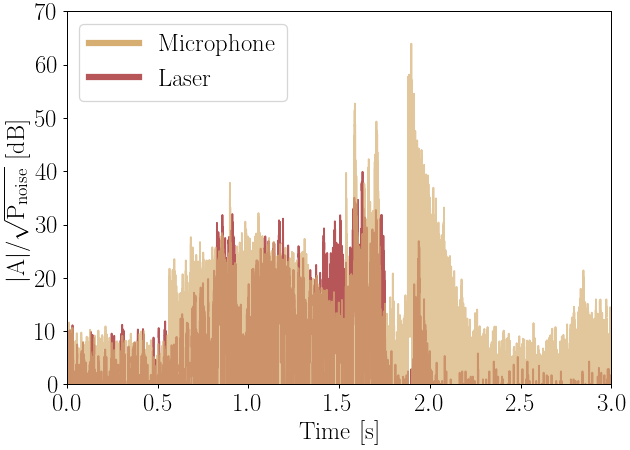

7991
Original data shape: (399500,)
Downsampled data shape: (399500,)
fs: 19586.063861059847
MIC rest_power: 5438381.42 ; signal_power: 2116644251.17; sensitivity: 19.73=25.9dB 
680
Original data shape: (67900,)
Downsampled data shape: (67900,)
fs: 3634.7625694398907
LASER rest_power: 0.00 ; signal_power: 0.02; sensitivity: 11.43=21.2dB 
-------------- Laser is 0.58=-4.7dB times more sensitive than mic


In [44]:
%matplotlib notebook

time_axis_offset = 10
fig = plt.figure(figsize=(7, 5), constrained_layout=True)
downsampling = 1
data_directory = os.path.join(os.getcwd(), "box")


laser_data, laser_time_axis, laser_rest_power, mic_data, mic_time_axis, mic_rest_power = parse_sensor_data(
    data_directory=data_directory, mic_file_name='box_mic.csv', laser_file_name='box_laser.csv', 
    downsampling=downsampling, time_axis_offset=time_axis_offset, 
    mic_signal_range=(213000, 230000), laser_signal_range=(33700, 36850),
    mic_rest_range=(int(1e4), int(1e5)), laser_rest_range=(0, 30000))


plt.axvline(-10, linewidth=5, color=mic_color)
plt.axvline(-10, linewidth=5, color=laser_color)
plt.plot(laser_time_axis, 20*np.log10(abs(laser_data/np.sqrt(laser_rest_power))), alpha=1, color=laser_color)
plt.plot(mic_time_axis, 20*np.log10(abs(mic_data/np.sqrt(mic_rest_power))), alpha=0.7, color=mic_color)
#plt.plot(laser_data/np.sqrt(laser_rest_power), alpha=1, color=laser_color)
#plt.plot(mic_data/np.sqrt(mic_rest_power), alpha=0.7, color=mic_color)

'''plt.axvline(laser_time_axis[laser_slip_range[0]], linewidth=1, color='black')
plt.axvline(laser_time_axis[laser_slip_range[1]], linewidth=1, color='black')
plt.axvline(mic_time_axis[slip_range[0]], linewidth=1, color='black')
plt.axvline(mic_time_axis[slip_range[1]], linewidth=1, color='black')'''

plt.xlim([0, 3])
plt.ylim([0, 70])
plt.xlabel('Time [s]')
plt.ylabel('$|$A$|$/$\sqrt{\mathrm{P}_{\mathrm{noise}}}$ [dB]')
plt.legend(["Microphone", "Laser"])
plt.show()

#plt.savefig('box_plot.svg')

## Box fast

<IPython.core.display.Javascript object>


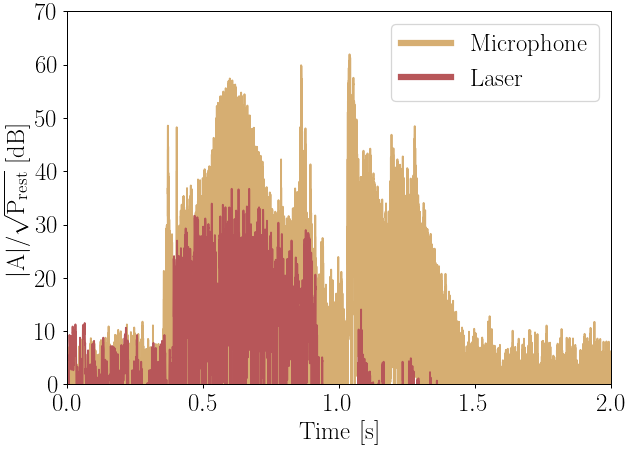

7874
Original data shape: (393650,)
Downsampled data shape: (393650,)
fs: 19425.99335593029
MIC rest_power: 6502913.76 ; signal_power: 97309689140.72; sensitivity: 122.33=41.8dB 
675
Original data shape: (67400,)
Downsampled data shape: (67400,)
fs: 3635.051409280847
LASER rest_power: 0.00 ; signal_power: 0.13; sensitivity: 16.01=24.1dB 
-------------- Laser is 0.13=-17.7dB times more sensitive than mic


In [36]:
%matplotlib notebook

time_axis_offset = 8.5
fig = plt.figure(figsize=(7, 5), constrained_layout=True)
downsampling = 1
data_directory = os.path.join(os.getcwd(), "box")


laser_data, laser_time_axis, laser_rest_power, mic_data, mic_time_axis, mic_rest_power = parse_sensor_data(
    data_directory=data_directory, mic_file_name='box_fast_mic.csv', laser_file_name='box_fast_laser.csv', 
    downsampling=downsampling, time_axis_offset=time_axis_offset, 
    mic_signal_range=(173500, 181500), laser_signal_range=(26750, 28350),
    mic_rest_range=(20000, int(1e5)), laser_rest_range=(0, 20000))


plt.axvline(-10, linewidth=5, color=mic_color)
plt.axvline(-10, linewidth=5, color=laser_color)
plt.plot(mic_time_axis, 20*np.log10(abs(mic_data/np.sqrt(mic_rest_power))), alpha=1, color=mic_color)
plt.plot(laser_time_axis, 20*np.log10(abs(laser_data/np.sqrt(laser_rest_power))), alpha=1, color=laser_color)
#plt.plot(mic_data/np.sqrt(mic_rest_power), alpha=1, color=mic_color)
#plt.plot(laser_data/np.sqrt(laser_rest_power), alpha=1, color=laser_color)

'''plt.axvline(laser_time_axis[laser_slip_range[0]], linewidth=1, color='black')
plt.axvline(laser_time_axis[laser_slip_range[1]], linewidth=1, color='black')
plt.axvline(mic_time_axis[slip_range[0]], linewidth=1, color='black')
plt.axvline(mic_time_axis[slip_range[1]], linewidth=1, color='black')'''

plt.xlim([0, 2])
plt.ylim([0, 70])
plt.xlabel('Time [s]')
plt.ylabel('$|$A$|$/$\sqrt{\mathrm{P}_{\mathrm{noise}}}$ [dB]')
plt.legend(["Microphone", "Laser"])
plt.show()

plt.savefig('box_plot_fast.svg')

# Pencil

## Pencil no external noise

<IPython.core.display.Javascript object>


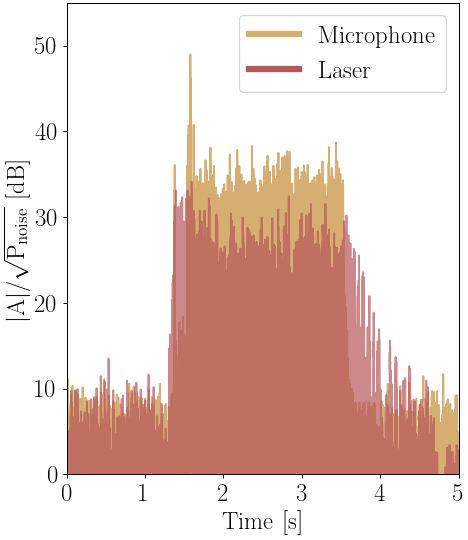

4688
Original data shape: (234350,)
Downsampled data shape: (234350,)
fs: 20260.3544157155
MIC rest_power: 9148673.80 ; signal_power: 2559122172.24; sensitivity: 16.73=24.5dB 
364
Original data shape: (36300,)
Downsampled data shape: (36300,)
fs: 3635.2631339653553
LASER rest_power: 0.00 ; signal_power: 0.06; sensitivity: 9.89=19.9dB 
-------------- Laser is 0.59=-4.6dB times more sensitive than mic


In [39]:
%matplotlib notebook


time_axis_offset = 2
fig = plt.figure(figsize=(5.2, 6), constrained_layout=True)
downsampling = 1
data_directory = os.path.join(os.getcwd(), "pencil")


laser_data, laser_time_axis, laser_rest_power, mic_data, mic_time_axis, mic_rest_power = parse_sensor_data(
    data_directory=data_directory, mic_file_name='pencil_mic.csv', laser_file_name='pencil_laser.csv', 
    downsampling=downsampling, time_axis_offset=time_axis_offset, 
    mic_signal_range=(77000, 106000), laser_signal_range=(9000, 14000),
    mic_rest_range=(0, int(5e4)), laser_rest_range=(0, 6000))

plt.axvline(-10, linewidth=5, color=mic_color)
plt.axvline(-10, linewidth=5, color=laser_color)
plt.plot(mic_time_axis, 20*np.log10(abs(mic_data/np.sqrt(mic_rest_power))), alpha=1, color=mic_color)
plt.plot(laser_time_axis, 20*np.log10(abs(laser_data/np.sqrt(laser_rest_power))), alpha=0.7, color=laser_color)
#plt.plot(mic_data/np.sqrt(mic_rest_power), alpha=1, color=mic_color)
#plt.plot(laser_data/np.sqrt(laser_rest_power), alpha=0.7, color=laser_color)

'''plt.axvline(laser_time_axis[laser_slip_range[0]], linewidth=1, color='black')
plt.axvline(laser_time_axis[laser_slip_range[1]], linewidth=1, color='black')
plt.axvline(mic_time_axis[slip_range[0]], linewidth=1, color='black')
plt.axvline(mic_time_axis[slip_range[1]], linewidth=1, color='black')'''

plt.xlim([0, 5])
plt.ylim([0, 55])
plt.xlabel('Time [s]')
plt.ylabel('$|$A$|$/$\sqrt{\mathrm{P}_{\mathrm{noise}}}$ [dB]')
plt.legend(["Microphone", "Laser"])
plt.show()

plt.savefig('pencil_plot_noNoise.png')

## Pencil with external noise

<IPython.core.display.Javascript object>


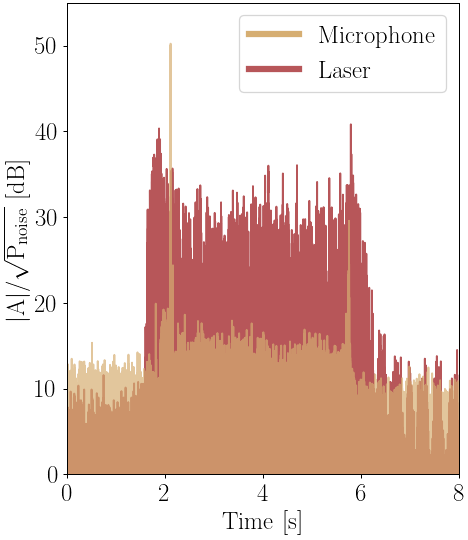

7070
Original data shape: (353450,)
Downsampled data shape: (353450,)
fs: 19685.400071991367
MIC rest_power: 418323048.71 ; signal_power: 1312708828.56; sensitivity: 1.77=5.0dB 
590
Original data shape: (58900,)
Downsampled data shape: (58900,)
fs: 3635.278270985122
LASER rest_power: 0.00 ; signal_power: 0.03; sensitivity: 11.63=21.3dB 
-------------- Laser is 6.56=16.3dB times more sensitive than mic


In [43]:
%matplotlib notebook

time_axis_offset = 6
fig = plt.figure(figsize=(5.2, 6), constrained_layout=True)
downsampling = 1
data_directory = os.path.join(os.getcwd(), "pencil")


laser_data, laser_time_axis, laser_rest_power, mic_data, mic_time_axis, mic_rest_power = parse_sensor_data(
    data_directory=data_directory, mic_file_name='pencil_mic_noise.csv', laser_file_name='pencil_laser_noise.csv', 
    downsampling=downsampling, time_axis_offset=time_axis_offset, 
    mic_signal_range=(170000, 220000), laser_signal_range=(25000, 36000),
    mic_rest_range=(int(3e5), int(3.1e5)), laser_rest_range=(0, 15000))


plt.axvline(-10, linewidth=5, color=mic_color)
plt.axvline(-10, linewidth=5, color=laser_color)
plt.plot(laser_time_axis, 20*np.log10(abs(laser_data/np.sqrt(laser_rest_power))), alpha=1, color=laser_color)
plt.plot(mic_time_axis, 20*np.log10(abs(mic_data/np.sqrt(mic_rest_power))), alpha=0.7, color=mic_color)
#plt.plot(laser_data/np.sqrt(laser_rest_power), alpha=1, color=laser_color)
#plt.plot(mic_data/np.sqrt(mic_rest_power), alpha=1, color=mic_color)


plt.xlim([0, 8])
plt.ylim([0, 55])
plt.xlabel('Time [s]')
plt.ylabel('$|$A$|$/$\sqrt{\mathrm{P}_{\mathrm{noise}}}$ [dB]')
plt.legend(["Microphone", "Laser"])
plt.show()

plt.savefig('pencil_plot_noise.svg')

### No pencil

<IPython.core.display.Javascript object>


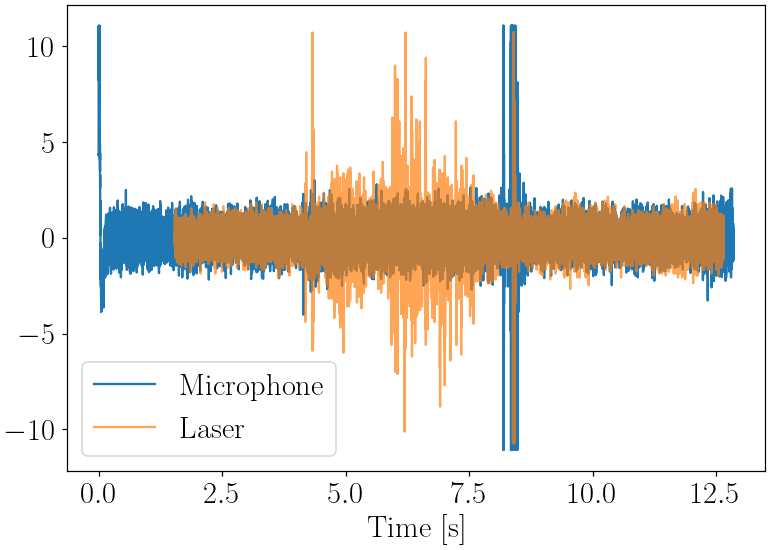

5051
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 50', 'refresh_rate_hz None']
Original data shape: (252500,)
Downsampled data shape: (252500,)
fs: 19649.599011994815
rest_power: 63311643.83559764
405
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 100', 'refresh_rate_hz None']
Original data shape: (40400,)
Downsampled data shape: (40400,)
fs: 3635.7778539731225
rest_power: 4.167413543220185e-05


In [7]:
# 
#
#        Same movement, no pencil in hand, to characterise motor noise
#
#

%matplotlib notebook

fig = plt.figure(figsize=(7, 5), constrained_layout=True)
downsampling = 1
data_directory = os.path.join(os.getcwd(), "pencil")


file_name = 'pencil_mic_moveOnly.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
mic_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

data = np.clip(data - np.mean(data), -50000, 50000)
num_samples = 20000
rest_power = np.sum(np.array(data[0:num_samples])**2)/num_samples
power = np.sum(np.array(data)**2)/len(list(data))
print(f'rest_power: {rest_power}')

#plt.plot(time_axis, abs(data)/np.sqrt(rest_power))
plt.plot(time_axis, data/np.sqrt(power), alpha=1)



file_name = 'pencil_laser_moveOnly.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
laser_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time_axis = np.array(time_axis) + (laser_start_timestamp - mic_start_timestamp).total_seconds()
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

data = np.clip(data - np.mean(data), -0.13, 0.13)
num_samples = 3600
rest_power = np.sum(np.array(data[100:num_samples+100])**2)/num_samples
power = np.sum(np.array(data)**2)/len(list(data))
print(f'rest_power: {rest_power}')

plt.plot(time_axis, data/np.sqrt(power), alpha=0.7)



plt.xlabel('Time [s]')
#plt.ylim([-12, 12])
plt.legend(["Microphone", "Laser"])
plt.show()



## Laser pencil vs no pencil

<IPython.core.display.Javascript object>


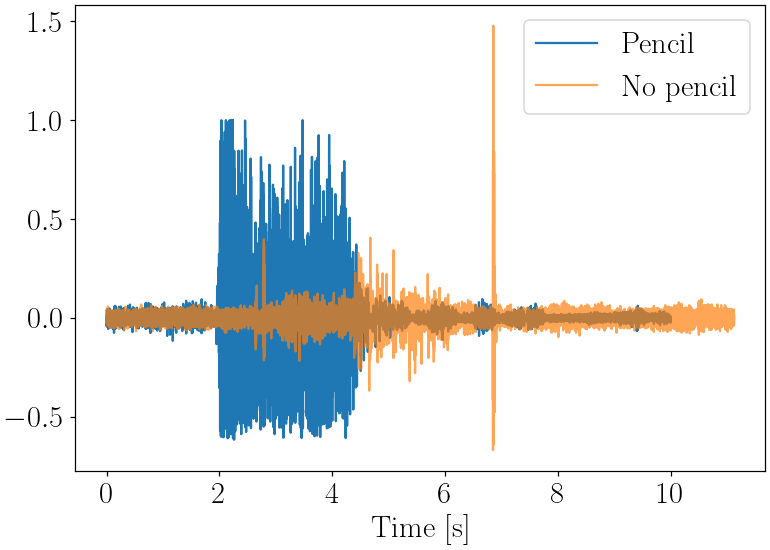

364
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 100', 'refresh_rate_hz None']
Original data shape: (36300,)
Downsampled data shape: (36300,)
fs: 3635.2631339653553
rest_power: 0.000496212350644023
405
['fs 3700', 'frames_per_buffer None', 'samples_per_frame 100', 'refresh_rate_hz None']
Original data shape: (40400,)
Downsampled data shape: (40400,)
fs: 3635.7778539731225
rest_power: 4.167413543220185e-05


In [6]:
# 
#
#        Same movement, no pencil in hand, to characterise motor noise
#
#

%matplotlib notebook


fig = plt.figure(figsize=(7, 5), constrained_layout=True)
downsampling = 1

data_directory = os.path.join(os.getcwd(), "pencil")
file_name = 'pencil_laser.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
mic_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

data = np.clip(data - np.mean(data), -1, 1)
num_samples = 3600
rest_power = np.sum(np.array(data[0:num_samples])**2)/num_samples
power = np.sum(np.array(data)**2)/len(list(data))
print(f'rest_power: {rest_power}')

#plt.plot(time_axis, abs(data)/np.sqrt(rest_power))
plt.plot(time_axis, data, alpha=1)





downsampling = 1

data_directory = "/home/idlab403/data/LaserMic"
file_name = 'pencil_laser_moveOnly.csv'

data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling)
laser_start_timestamp = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
time_difference = (time2 - time1).total_seconds()
fs = len(data)/time_difference / downsampling
print(f'fs: {fs}')

data = np.clip(data - np.mean(data), -1, 1)
num_samples = 3600
rest_power = np.sum(np.array(data[100:num_samples+100])**2)/num_samples
power = np.sum(np.array(data)**2)/len(list(data))
print(f'rest_power: {rest_power}')

plt.plot(time_axis, 3*data, alpha=0.7)



plt.xlabel('Time [s]')
#plt.ylim([-12, 12])
plt.legend(["Pencil", "No pencil"])
plt.show()



# Cup

In [6]:
import scipy.signal as scpysignal

def plot_with_peak_detect(axis, data_directory, file_name, peak_search_config, 
                          rest_power_ranges, noise_power_ranges,
                          color, x_view_range, cutoff=0, alpha=1, time_axis_offset=0, log=True, downsampling=1):
    data, header, timestamps, time_axis = read_data(data_directory, file_name, downsampling=downsampling)
    time1 = datetime.strptime(timestamps[0], '%Y-%m-%d %H:%M:%S.%f')
    time2 = datetime.strptime(timestamps[-1], '%Y-%m-%d %H:%M:%S.%f')
    time_difference = (time2 - time1).total_seconds()
    fs = len(data)/time_difference
    print(f'fs: {fs}')


    time_axis, data = get_time_data(data, fs, view_range=None)
    data = abs(data - np.mean(data))
    num_samples = 0
    rest_power = 0
    for rest_power_range in rest_power_ranges:
        data_range = np.array(data[rest_power_range[0]:rest_power_range[1]])
        num_samples += len(list(data_range))
        rest_power += np.sum((data_range - np.mean(data_range))**2)
    rest_power /= num_samples
    rest_power_log = 10*np.log10(rest_power)

    num_samples = 0
    noise_power = 0
    for noise_power_range in noise_power_ranges:
        data_range = np.array(data[noise_power_range[0]:noise_power_range[1]])
        num_samples += len(list(data_range))
        noise_power += np.sum((data_range - np.mean(data_range))**2)
    noise_power /= num_samples
    noise_power_log = 10*np.log10(noise_power)

    print(f'rest_power: {rest_power} ; rest_power_log: {rest_power_log}')
    print(f'noise_power: {noise_power} ; noise_power_log: {noise_power_log}')


    time_axis = np.array(time_axis[cutoff:])
    data = data[cutoff:]
    peak_sets = []
    for peak_search in peak_search_config:
        search_range = peak_search['sample_range']
        peaks, peak_properties = scpysignal.find_peaks(data[search_range[0]:search_range[1]], height=peak_search['height'], distance=peak_search['distance'])
        peaks = np.array(peaks) + search_range[0]
        peak_sets.append({"type": peak_search["type"], "peaks": np.array(peaks), "peak_heights": np.array(peak_properties['peak_heights'])})

    time_axis -= time_axis_offset
    time_axis_len = x_view_range[1] - x_view_range[0]
    #axis.plot(abs(data), color=color, zorder=-1, alpha=alpha)
    if log:
        axis.plot(time_axis, 20*np.log10(abs(data)) - rest_power_log, color=color, zorder=-1, alpha=alpha)
    else:
        axis.plot(time_axis, abs(data)/np.sqrt(rest_power), color=color, zorder=-1, alpha=alpha)
    
    for peak_set in peak_sets:
        if log:
            if peak_set["type"] == "NORMAL":
                axis.scatter(time_axis[peak_set["peaks"]], 20*np.log10(peak_set["peak_heights"]) - rest_power_log, marker='x', color="black", zorder=1)
            elif peak_set["type"] == "EXTERNAL":
                axis.scatter(time_axis[peak_set["peaks"]], 20*np.log10(peak_set["peak_heights"]) - rest_power_log, marker='x', color="black", zorder=1)
            # peak_mean calculated with average energy of the peaks
            peak_mean = 10*np.log10(np.mean(abs(peak_set["peak_heights"])**2)) - rest_power_log
        else:
            if peak_set["type"] == "NORMAL":
                axis.scatter(time_axis[peak_set["peaks"]], abs(peak_set["peak_heights"])/np.sqrt(rest_power), marker='o', color=color, zorder=1)
            elif peak_set["type"] == "EXTERNAL":
                axis.plot(time_axis[peak_set["peaks"]], abs(peak_set["peak_heights"])/np.sqrt(rest_power), linestyle='none', marker='s', color=color, zorder=1)
            # peak_mean calculated with average energy of the peaks
            peak_mean = np.sqrt(np.mean(abs(peak_set["peak_heights"])**2)/rest_power)
        axis.axhline(peak_mean, 
                     time_axis[peak_set["peaks"][0]]/time_axis_len, 
                     time_axis[peak_set["peaks"][-1]]/time_axis_len, color=color, linestyle='--', zorder=2)
        axis.text(time_axis[peak_set["peaks"][0]] - 1, peak_mean, f'{peak_mean:.1f}', horizontalalignment='right', verticalalignment='center')
    


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Soft silicone without external noise

<IPython.core.display.Javascript object>


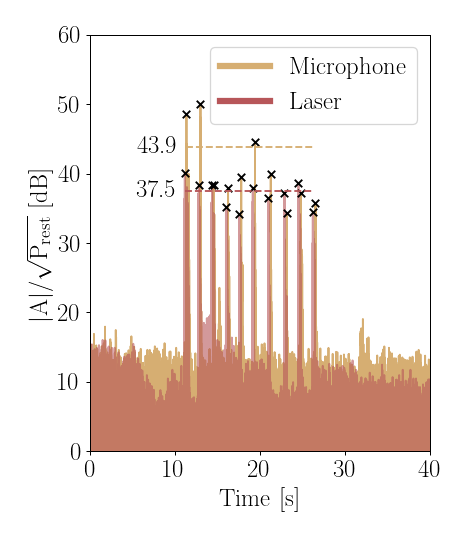

==================MIC==================
24349
Original data shape: (1217400,)
Downsampled data shape: (121740,)
fs: 2008.4862586477593
No view range passed, using (0, 121740)
rest_power: 3436674.214905884 ; rest_power_log: 65.361383644402
noise_power: 3465259.3130963403 ; noise_power_log: 65.39735739390245
==================LASER==================
3769
Original data shape: (1130400,)
Downsampled data shape: (113040,)
fs: 1868.2974889562777
No view range passed, using (0, 113040)
rest_power: 0.0003524629254770605 ; rest_power_log: -34.52886558410239
noise_power: 0.00010366135901385793 ; noise_power_log: -39.843831018021945


In [9]:
%matplotlib notebook

downsampling = 10
fig, axes = plt.subplots(1, 1, figsize=(5.2, 6))
axes.axvline(-10, linewidth=5, color=mic_color)
axes.axvline(-10, linewidth=5, color=laser_color)


x_view_range = [0, 40]
time_axis_offset = 20
data_directory = os.path.join(os.getcwd(), "cup")
idx = 1
print('==================MIC==================')
file_name = f'soft_silicone_mic{idx}.csv'
peak_search_config = [{"type": "NORMAL", "height" : 5e4, "distance": 3e4/downsampling, "sample_range": (int(2e5/downsampling), int(12e5/downsampling))}]
plot_with_peak_detect(axes, data_directory, file_name, rest_power_ranges=[(int(1e6/downsampling), -1)], 
                      noise_power_ranges=[(0, 1000)], 
                      peak_search_config=peak_search_config, cutoff=0, color=mic_color, alpha=1, time_axis_offset=time_axis_offset, x_view_range=x_view_range, downsampling=downsampling)

print('==================LASER==================')
file_name = f'soft_silicone_laser{idx}.csv'
peak_search_config = [{"type": "NORMAL", "height" : 0.2, "distance": 2e4/downsampling, "sample_range": (int(2e5/downsampling), int(11e5/downsampling))}]
plot_with_peak_detect(axes, data_directory, file_name, rest_power_ranges=[(int(2e5/downsampling), int(4.5e5/downsampling))], noise_power_ranges=[(0, 1000)], peak_search_config=peak_search_config, cutoff=0, color=laser_color, alpha=0.6, time_axis_offset=time_axis_offset, x_view_range=x_view_range, downsampling=downsampling)

axes.set_xlim(x_view_range)
axes.set_ylim([0, 60])
axes.set_xlabel('Time [s]')
axes.set_ylabel('$|$A$|$/$\sqrt{\mathrm{P}_{\mathrm{noise}}}$ [dB]')
axes.legend(["Microphone", "Laser"])
fig.tight_layout()
fig.savefig('silicone_plot.svg')
fig.show()

## Soft silicone with external noise

<IPython.core.display.Javascript object>


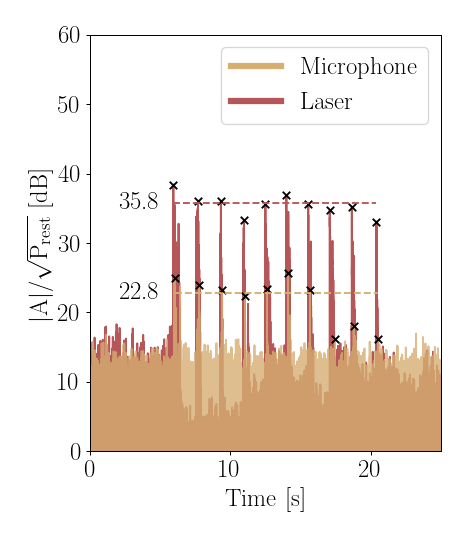

==================LASER==================
3559
Original data shape: (1067400,)
Downsampled data shape: (106740,)
fs: 1867.4350641182448
No view range passed, using (0, 106740)
rest_power: 0.0004108116510411724 ; rest_power_log: -33.86357247861673
noise_power: 0.00022231226954101427 ; noise_power_log: -36.53036567679277
==================MIC==================
23119
Original data shape: (1155900,)
Downsampled data shape: (115590,)
fs: 2016.7356431897572
No view range passed, using (0, 115590)
rest_power: 685664170.1945646 ; rest_power_log: 88.36111455731456
noise_power: 613750028.55785 ; noise_power_log: 87.8799152533879


In [8]:
%matplotlib notebook

downsampling = 10
fig, axes = plt.subplots(1, 1, figsize=(5.2, 6))
axes.axvline(-10, linewidth=5, color=mic_color)
axes.axvline(-10, linewidth=5, color=laser_color)

x_view_range = [0, 25]
time_axis_offset = 25
data_directory = os.path.join(os.getcwd(), "cup")
idx = 1

print('==================LASER==================')
file_name = f'soft_silicone_noise_laser{idx}.csv'
peak_search_config = [{"type": "NORMAL", "height" : 0.3, "distance": 2e4/downsampling, "sample_range": (int(2e5/downsampling), int(11e5/downsampling))}]
plot_with_peak_detect(axes, data_directory, file_name, rest_power_ranges=[(int(2e5/downsampling), int(4.5e5/downsampling))], noise_power_ranges=[(0, int(1000/downsampling))], peak_search_config=peak_search_config, cutoff=0, color=laser_color, alpha=1, time_axis_offset=time_axis_offset, x_view_range=x_view_range, downsampling=downsampling)

print('==================MIC==================')
file_name = f'soft_silicone_noise_mic{idx}.csv'
peak_search_config = [{"type": "NORMAL", "height" : 1.5e5, "distance": 2e4/downsampling, "sample_range": (int(6.1e5/downsampling), int(9.4e5/downsampling))}]
plot_with_peak_detect(axes, data_directory, file_name, rest_power_ranges=[(int(1e6/downsampling), -1)], noise_power_ranges=[(0, int(1000/downsampling))], peak_search_config=peak_search_config, cutoff=0, color=mic_color, alpha=0.8, time_axis_offset=time_axis_offset, x_view_range=x_view_range, downsampling=downsampling)

axes.set_xlim(x_view_range)
axes.set_ylim([0, 60])
axes.set_xlabel('Time [s]')
axes.set_ylabel('$|$A$|$/$\sqrt{\mathrm{P}_{\mathrm{noise}}}$ [dB]')
axes.legend(["Microphone", "Laser"])
fig.tight_layout()
fig.savefig('silicone_noise.svg')
fig.show()

## Bolts without external noise

<IPython.core.display.Javascript object>


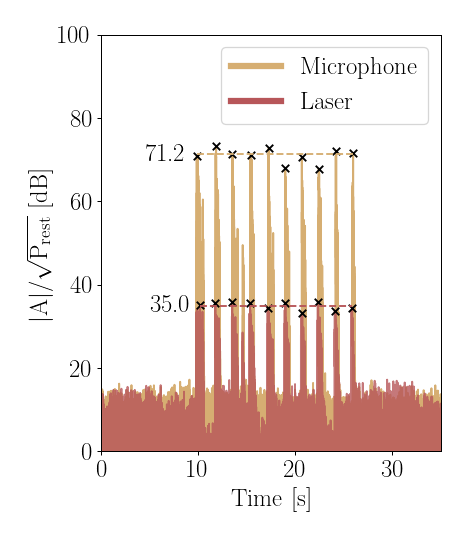

==================MIC==================
16119
Original data shape: (805900,)
Downsampled data shape: (80590,)
fs: 2012.921009647609
No view range passed, using (0, 80590)
rest_power: 2758408.02942787 ; rest_power_log: 64.40658508330793
noise_power: 2131569.7003766214 ; noise_power_log: 63.28699538247068
==================LASER==================
2489
Original data shape: (746400,)
Downsampled data shape: (74640,)
fs: 1869.427127281088
No view range passed, using (0, 74640)
rest_power: 0.0011204892906281514 ; rest_power_log: -29.505922899931104
noise_power: 0.0009110801075300169 ; noise_power_log: -30.404434356189686


In [26]:
%matplotlib notebook

downsampling = 10
fig, axes = plt.subplots(1, 1, figsize=(5.2, 6))
axes.axvline(-10, linewidth=5, color=mic_color)
axes.axvline(-10, linewidth=5, color=laser_color)

x_view_range = [0, 35]
time_axis_offset = 0
data_directory = os.path.join(os.getcwd(), "cup")
idx = 2
print('==================MIC==================')
file_name = f'bolts_mic{idx}.csv'
peak_search_config = [{"type": "NORMAL", "height" : 1.5e5, "distance": 2e4/downsampling, "sample_range": (int(19e4/downsampling), int(6.2e5/downsampling))}]
plot_with_peak_detect(axes, data_directory, file_name, rest_power_ranges=[(int(6.2e5/downsampling), -1)], noise_power_ranges=[(0, int(1000/downsampling))], peak_search_config=peak_search_config, cutoff=0, color=mic_color, alpha=1, time_axis_offset=time_axis_offset, x_view_range=x_view_range, downsampling=downsampling)

print('==================LASER==================')
file_name = f'bolts_laser{idx}.csv'
peak_search_config = [{"type": "NORMAL", "height" : 0.5, "distance": 2e4/downsampling, "sample_range": (int(18e4/downsampling), int(57e4/downsampling))}]
plot_with_peak_detect(axes, data_directory, file_name, rest_power_ranges=[(0, int(11e4/downsampling))], noise_power_ranges=[(0, int(1000/downsampling))], peak_search_config=peak_search_config, cutoff=0, color=laser_color, alpha=0.8, time_axis_offset=time_axis_offset, x_view_range=x_view_range, downsampling=downsampling)


axes.set_xlim(x_view_range)
axes.set_ylim([0, 100])
axes.set_xlabel('Time [s]')
axes.set_ylabel('$|$A$|$/$\sqrt{\mathrm{P}_{\mathrm{noise}}}$ [dB]')
axes.legend(["Microphone", "Laser"])
fig.tight_layout()
fig.savefig('bolts_plot.svg')
fig.show()

## Bolts with external noise

<IPython.core.display.Javascript object>


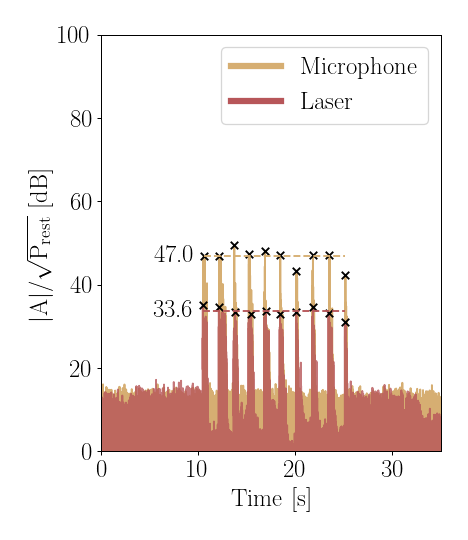

==================MIC==================
15889
Original data shape: (794400,)
Downsampled data shape: (79440,)
fs: 2011.2050247314419
No view range passed, using (0, 79440)
rest_power: 731544123.6787683 ; rest_power_log: 88.64240526076222
noise_power: 670423427.9101697 ; noise_power_log: 88.26349182284409
==================LASER==================
2449
Original data shape: (734400,)
Downsampled data shape: (73440,)
fs: 1860.4699708265439
No view range passed, using (0, 73440)
rest_power: 0.0016276961727522187 ; rest_power_log: -27.884266576847764
noise_power: 0.0007777940650440556 ; noise_power_log: -31.09135375059028


In [31]:
%matplotlib notebook

downsampling = 10
fig, axes = plt.subplots(1, 1, figsize=(5.2, 6))
axes.axvline(-10, linewidth=5, color=mic_color)
axes.axvline(-10, linewidth=5, color=laser_color)

x_view_range = [0, 35]
time_axis_offset = 0
data_directory = os.path.join(os.getcwd(), "cup")
idx = 2
print('==================MIC==================')
file_name = f'bolts_noise_mic{idx}.csv'
peak_search_config = [{"type": "NORMAL", "height" : 1.5e5, "distance": 2e4/downsampling, "sample_range": (int(20e4/downsampling), int(5.3e5/downsampling))}]
plot_with_peak_detect(axes, data_directory, file_name, rest_power_ranges=[(int(6.2e5/downsampling), -1)], noise_power_ranges=[(0, int(1000/downsampling))], peak_search_config=peak_search_config, cutoff=0, color=mic_color, alpha=1, time_axis_offset=time_axis_offset, x_view_range=x_view_range, downsampling=downsampling)

print('==================LASER==================')
file_name = f'bolts_noise_laser{idx}.csv'
peak_search_config = [{"type": "NORMAL", "height" : 0.5, "distance": 2e4/downsampling, "sample_range": (int(18e4/downsampling), int(57e4/downsampling))}]
plot_with_peak_detect(axes, data_directory, file_name, rest_power_ranges=[(0, int(11e4/downsampling))], noise_power_ranges=[(0, int(1000/downsampling))], peak_search_config=peak_search_config, cutoff=0, color=laser_color, alpha=0.8, time_axis_offset=time_axis_offset, x_view_range=x_view_range, downsampling=downsampling)


axes.set_xlim(x_view_range)
axes.set_ylim([0, 100])
axes.set_xlabel('Time [s]')
axes.set_ylabel('$|$A$|$/$\sqrt{\mathrm{P}_{\mathrm{noise}}}$ [dB]')
axes.legend(["Microphone", "Laser"])
fig.tight_layout()
fig.savefig('bolts_noise_plot.svg')
fig.show()

In [50]:
silicone_pcs = [4.8, 3, 3.3, 2.8, 4.3, 4.7, 3.1, 4.4, 2.6, 3.1]
print(np.mean(silicone_pcs))
print(np.std(silicone_pcs))

3.6100000000000003
0.798060148109151
